(6362620, 11)
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object
isFraud
0    6354407
1       8213
Name: count, dtype: int64
isFraud
0   99.87
1    0.13
Name: proportion, dtype: float64
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64
            total  fraud_count  fraud_rate
type                                      
CASH_OUT  2237500         4116        0.18
TRANSFER   532909         4097        0.77
CASH_IN   1399284            0        0.00
DEBIT       41432            0        0.00
PAYMENT   2151495            0        0.00
(2770409, 11)


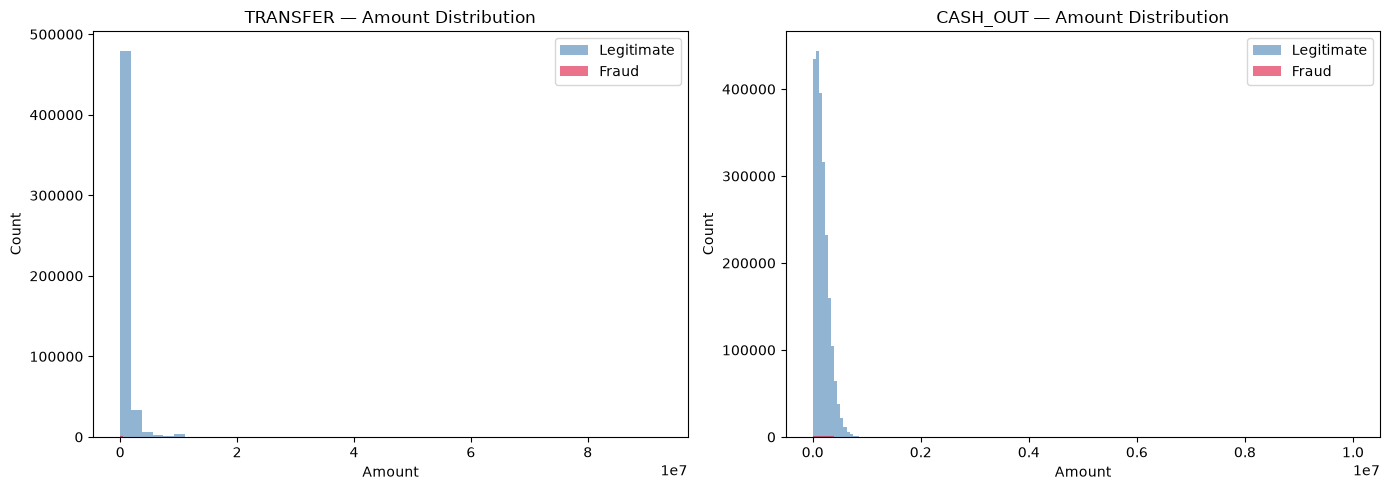

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


df=pd.read_csv('/Users/apple/Downloads/Portfolio/digital-payment-fraud-detection/data/ paysim_fraud.csv')
df.head()


print(df.shape)
print(df.dtypes)
df.isnull().sum()

print(df['isFraud'].value_counts())
print(df['isFraud'].value_counts(normalize=True) * 100)


print(df['type'].value_counts())
print()
print(df.groupby('type')['isFraud'].sum())



fraud_by_type = df.groupby('type').agg(
    total=('isFraud', 'count'),
    fraud_count=('isFraud', 'sum')
).assign(fraud_rate=lambda x: (x['fraud_count'] / x['total'] * 100).round(2))

print(fraud_by_type.sort_values('fraud_count', ascending=False))




df_model = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
print(df_model.shape)
print(df_model['isFraud'].value_counts())


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tx_type in zip(axes, ['TRANSFER', 'CASH_OUT']):
    subset = df_model[df_model['type'] == tx_type]
    ax.hist(subset[subset['isFraud'] == 0]['amount'], bins=50, alpha=0.6, label='Legitimate', color='steelblue')
    ax.hist(subset[subset['isFraud'] == 1]['amount'], bins=50, alpha=0.6, label='Fraud', color='crimson')
    ax.set_title(f'{tx_type} — Amount Distribution')
    ax.set_xlabel('Amount')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('../tableau/amount_distribution.png', dpi=150)
plt.show()





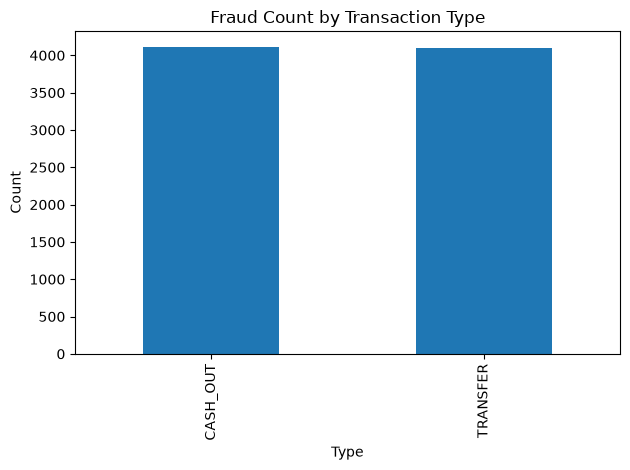

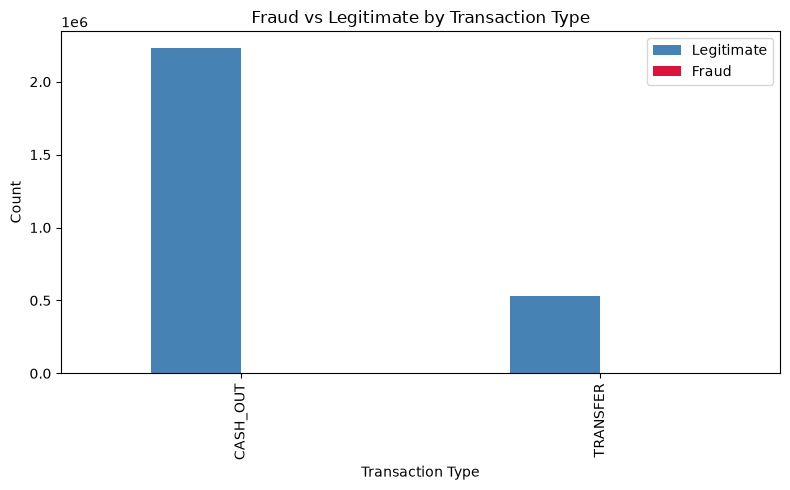

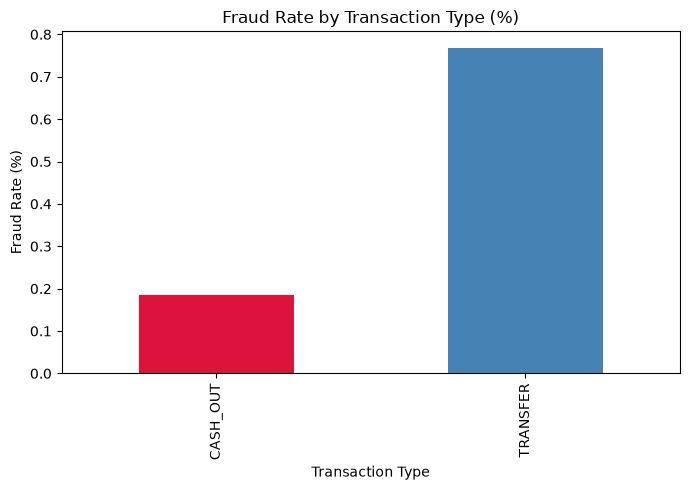

In [2]:
df_model['balance_diff_orig'] = df_model['oldbalanceOrg'] - df_model['newbalanceOrig']


df_model.groupby('isFraud')['balance_diff_orig'].mean()
                                                            

df_model['balance_diff_dest'] = df_model['oldbalanceDest'] - df_model['newbalanceDest']
df_model.groupby('isFraud')['newbalanceDest'].mean()

#df_model.head()


df_model['orig_balance_zero'] = (df_model['newbalanceOrig'] == 0).astype(int)
df_model.groupby('isFraud')['orig_balance_zero'].mean() * 100


fraud_only = df_model[df_model['isFraud'] == 1]
fraud_only['type'].value_counts().plot(kind='bar')
plt.title('Fraud Count by Transaction Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



type_fraud = df_model.groupby(['type', 'isFraud']).size().unstack()
type_fraud.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'crimson'])
plt.title('Fraud vs Legitimate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.legend(['Legitimate', 'Fraud'])
plt.tight_layout()
plt.show()

fraud_rate = df_model.groupby('type')['isFraud'].mean() * 100

fraud_rate.plot(kind='bar', figsize=(7, 5), color=['crimson', 'steelblue'])
plt.title('Fraud Rate by Transaction Type (%)')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()


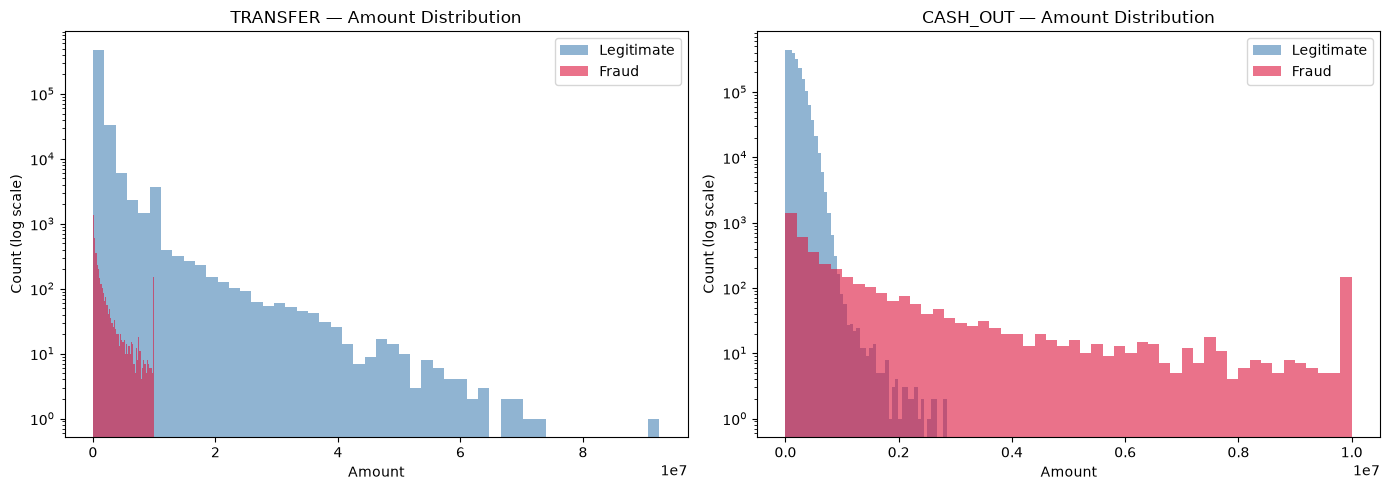

<Figure size 800x500 with 0 Axes>

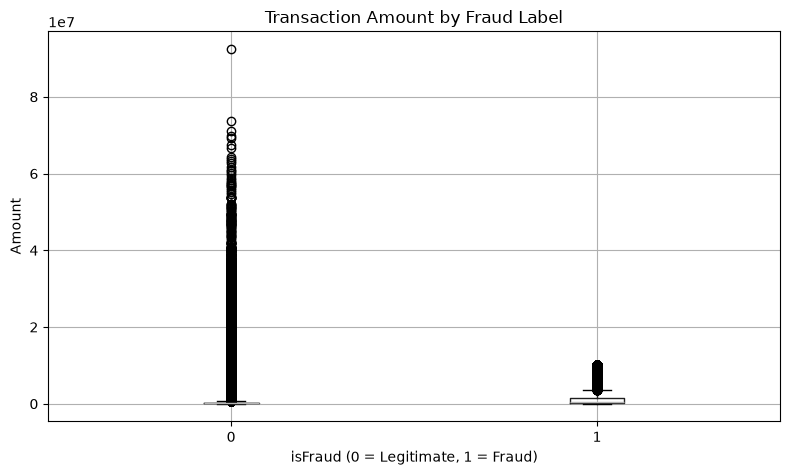

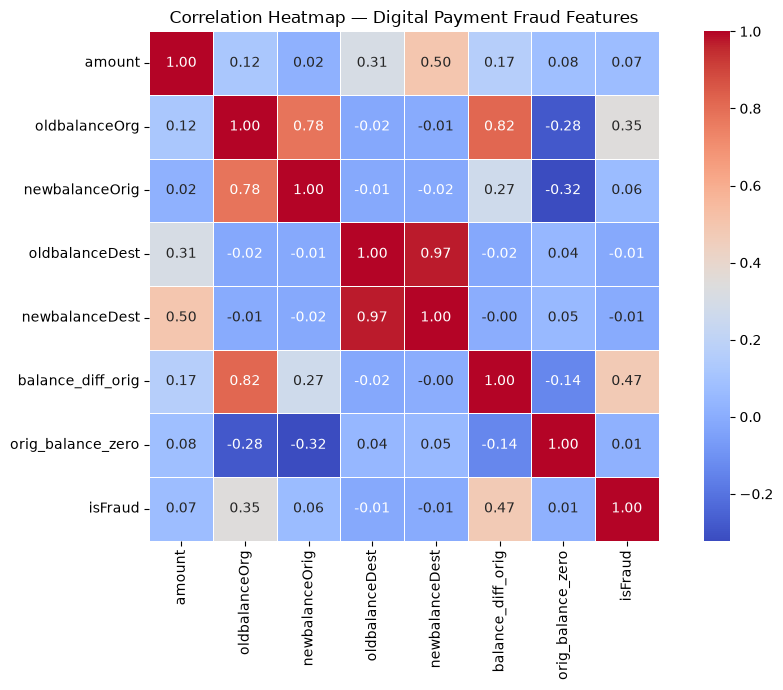

In [3]:
df_model.groupby('isFraud')['amount'].describe()


# Cell 18 — Amount distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tx_type in zip(axes, ['TRANSFER', 'CASH_OUT']):
    subset = df_model[df_model['type'] == tx_type]
    ax.hist(subset[subset['isFraud'] == 0]['amount'], bins=50, alpha=0.6, 
            label='Legitimate', color='steelblue', log=True)
    ax.hist(subset[subset['isFraud'] == 1]['amount'], bins=50, alpha=0.6, 
            label='Fraud', color='crimson', log=True)
    ax.set_title(f'{tx_type} — Amount Distribution')
    ax.set_xlabel('Amount')
    ax.set_ylabel('Count (log scale)')
    ax.legend()

plt.tight_layout()
plt.show()

# Cell 19 — Boxplot of amounts
plt.figure(figsize=(8, 5))
df_model.boxplot(column='amount', by='isFraud', figsize=(8, 5))
plt.title('Transaction Amount by Fraud Label')
plt.suptitle('')
plt.xlabel('isFraud (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()


# Cell 20 — Correlation heatmap
plt.figure(figsize=(10, 7))

numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 
                'oldbalanceDest', 'newbalanceDest', 
                'balance_diff_orig', 'orig_balance_zero', 'isFraud']

corr = df_model[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True)

plt.title('Correlation Heatmap — Digital Payment Fraud Features')
plt.tight_layout()
plt.show()

Train size: (2216327, 7)
Test size: (554082, 7)
Before SMOTE: {0: 2209757, 1: 6570}
After SMOTE: {0: 2209757, 1: 220975}
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.98    552439
       Fraud       0.09      0.97      0.16      1643

    accuracy                           0.97    554082
   macro avg       0.54      0.97      0.57    554082
weighted avg       1.00      0.97      0.98    554082



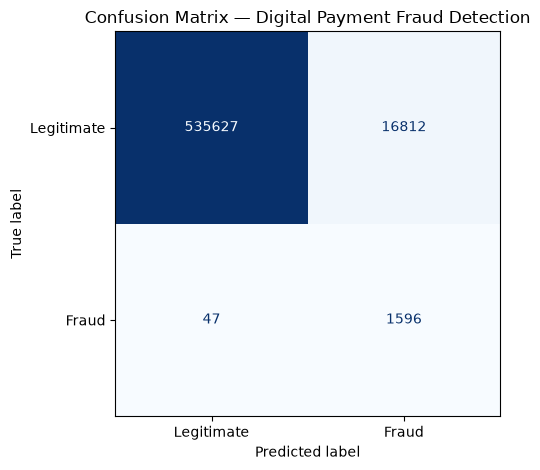

ROC-AUC Score: 0.9937


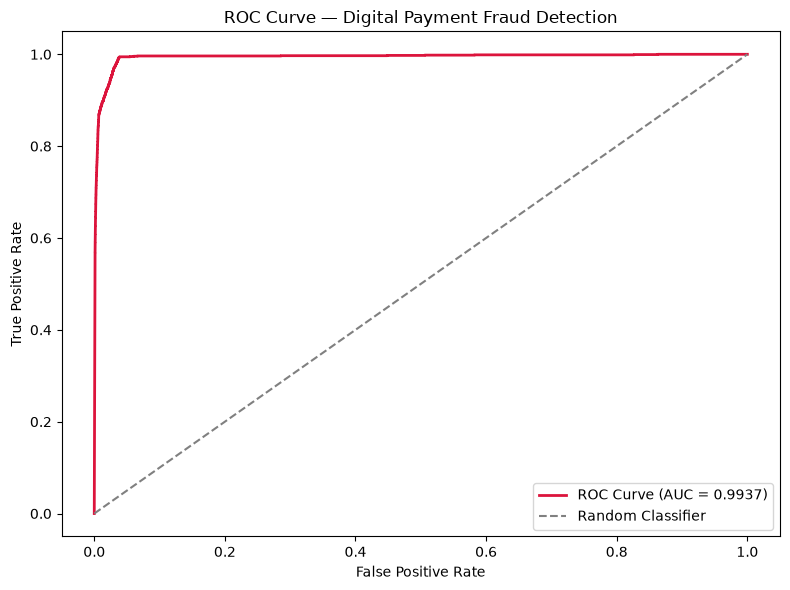

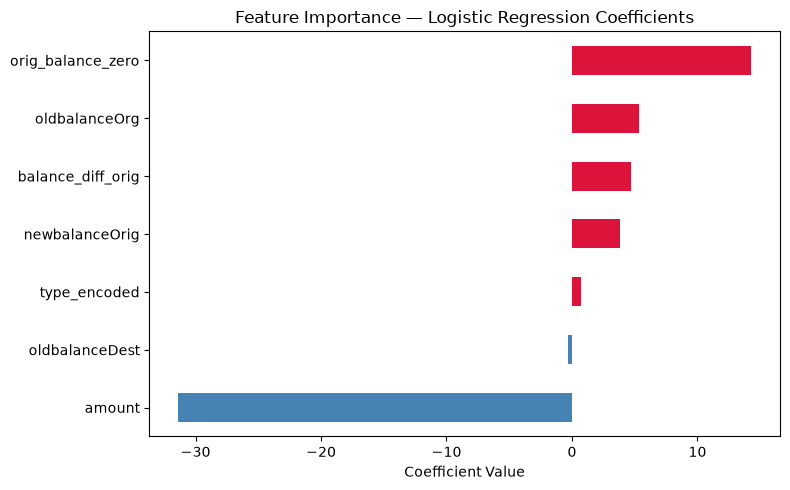

In [ ]:
# Cell 21 — Imports
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

# Cell 22 — Feature Engineering
df_model['type_encoded'] = (df_model['type'] == 'TRANSFER').astype(int)

features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 
            'oldbalanceDest', 'balance_diff_orig', 
            'orig_balance_zero', 'type_encoded']

X = df_model[features]
y = df_model['isFraud']

# Cell 23 — Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

# Cell 24 — Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Cell 25 — Handle Class Imbalance with SMOTE
sm = SMOTE(random_state=42, sampling_strategy=0.1)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

# Cell 26 — Train Logistic Regression
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_res, y_train_res)

# Cell 27 — Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Cell 28 — Classification Report
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

# Cell 29 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Digital Payment Fraud Detection')
plt.tight_layout()
plt.show()

# Cell 30 — ROC AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Cell 31 — ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Digital Payment Fraud Detection')
plt.legend()
plt.tight_layout()
plt.show()

# Cell 32 — Feature Importance
coefficients = pd.Series(model.coef_[0], index=features).sort_values()

plt.figure(figsize=(8, 5))
coefficients.plot(kind='barh', color=['crimson' if c > 0 else 'steelblue' for c in coefficients])
plt.title('Feature Importance — Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()





In [ ]:
# Save full filtered dataset
df_model.to_csv('../sql/fraud_model_data.csv', index=False)

# Save a fraud only subset
fraud_only = df_model[df_model['isFraud'] == 1]
fraud_only.to_csv('../sql/fraud_transactions.csv', index=False)

print(f"fraud_model_data.csv: {df_model.shape}")
print(f"fraud_transactions.csv: {fraud_only.shape}")